# Neural Network for Win Probability Prediction / Classification

In this notebook, we will create a simple fully connected neural network using Pytorch. We will evaluate the quality of the model when trained on the three different datasets used in the logistic regression Notebook.

# 1. Loading Data

In [255]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import copy
import random
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from utils import shuffle_data_df, train_test_split_df, standardise_cols, accuracy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_style("whitegrid")

df = pd.read_csv("../Data/full_data_enc.csv")

df.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
0,417,97,5.00,1170,28,1.14,0,18,1,0,...,0,0,0,1,0,0,0,0,0,0
1,440,97,3.50,1385,18,1.28,0,18,1,0,...,0,1,1,0,0,0,0,0,0,0
2,431,97,2.50,825,43,1.50,1,18,1,1,...,0,1,1,0,0,0,0,0,0,0
3,431,97,3.50,1230,24,1.28,1,18,1,1,...,0,1,0,1,0,0,0,0,0,0
4,431,97,2.75,770,48,1.39,0,18,1,1,...,0,1,0,0,1,0,0,0,0,0


In [256]:
# Shuffle data
df_shuff = shuffle_data_df(df)
df_shuff.head()

,dj_pts,dj_rank,dj_odds,opp_pts,opp_rank,opp_odds,dj_win,age,is_outdoor,is_five_sets,...,Grass,Hard,1st Round,2nd Round,3rd Round,4th Round,Quarterfinals,Round Robin,Semifinals,The Final
1057,8260,1,1.440,5750,5,2.75,1,35,1,0,...,0,0,0,0,0,0,0,0,0,1
938,12415,1,1.550,6620,3,2.60,1,32,1,1,...,1,0,0,0,0,0,0,0,0,1
1228,4580,5,1.170,1120,47,5.00,1,38,0,0,...,0,1,0,0,0,0,1,0,0,0
683,13845,1,1.002,603,87,34.00,1,28,1,1,...,0,0,1,0,0,0,0,0,0,0
282,7330,4,1.360,2195,15,3.20,1,22,1,0,...,0,1,0,0,0,0,0,0,0,1


In [257]:
# Train test split
df_train, df_test = train_test_split_df(df_shuff, 0.8)
df_train, df_val = train_test_split_df(df_train, 0.8)

In [258]:
# Separating target from predictors
y_train, y_val, y_test = df_train["dj_win"].to_numpy().reshape(-1, 1), df_val["dj_win"].to_numpy().reshape(-1, 1), df_test["dj_win"].to_numpy().reshape(-1, 1)
X_train, X_val, X_test = df_train.copy().drop(columns="dj_win").to_numpy(), df_val.drop(columns="dj_win").to_numpy(), df_test.drop(columns="dj_win").to_numpy()

In [259]:
# Standardise prediction matrix (only columns that are not one-hot-enc)
X_train_std = standardise_cols(X_train, range(7))
X_val_std = standardise_cols(X_val, range(7), X_train)
X_test_std = standardise_cols(X_test, range(7), X_train)

In [260]:
X_train_t = torch.tensor(X_train_std, dtype=torch.float32)
y_train_t = torch.tensor(y_train,     dtype=torch.float32)

X_val_t = torch.tensor(X_val_std, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test_std, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

# 2. Creating Network

Having loaded the data we need, we will now create our neural network, and specifiy loss and optimiser before we begin to train it and assess it's performance.

In [261]:
train_ds     = TensorDataset(X_train_t, y_train_t)
g = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, generator=g)

In [262]:
class NeuralNetwork(nn.Module):
    def __init__(self, features):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Linear(features, 4 * features),
            nn.ReLU(),
            nn.Linear(4 * features, 1))

    def forward(self, X):
        logits = self.layer(X)
        return torch.sigmoid(logits) # returns probabilities

In [263]:
model = NeuralNetwork(30) # we have 30 features
print(model)

NeuralNetwork(
  (layer): Sequential(
    (0): Linear(in_features=30, out_features=120, bias=True)
    (1): ReLU()
    (2): Linear(in_features=120, out_features=1, bias=True)
  )
)


# 3. Training and Evaluating the Network on Full Dataset

In [264]:
def train(dataloader, model, loss, optim, epochs, X_val, y_val):

    train_losses = []
    val_losses = []
    best_val, best_state, patience, no_improve = float("inf"), None, 50, 0

    for epoch in range(epochs):

        if (epoch + 1) % 50 == 0:
            print("Epoch number", epoch + 1)
        batch_losses = []
        model.train()

        for (X, y) in dataloader:

            optim.zero_grad()
            batch_loss = loss(model.forward(X), y)
            batch_losses.append(batch_loss.item())
            batch_loss.backward()
            optim.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss(model.forward(X_val), y_val).item()

        train_losses.append(np.mean(batch_losses))
        val_losses.append(val_loss)

        if val_loss < best_val:
            best_val, best_state, no_improve, best_epoch = val_loss, copy.deepcopy(model.state_dict()), 0, epoch

        else:
            no_improve += 1
            if no_improve > patience:
                break

    model.load_state_dict(best_state)   # roll back to the best epoch

    return train_losses, val_losses, best_epoch

In [265]:
model = NeuralNetwork(30)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss = nn.BCELoss()

In [266]:
train_losses, val_losses, best_epoch = train(train_loader, model, loss, opt, 1000, X_val_t, y_val_t)

Epoch number 50


In [267]:
print(best_epoch)

9


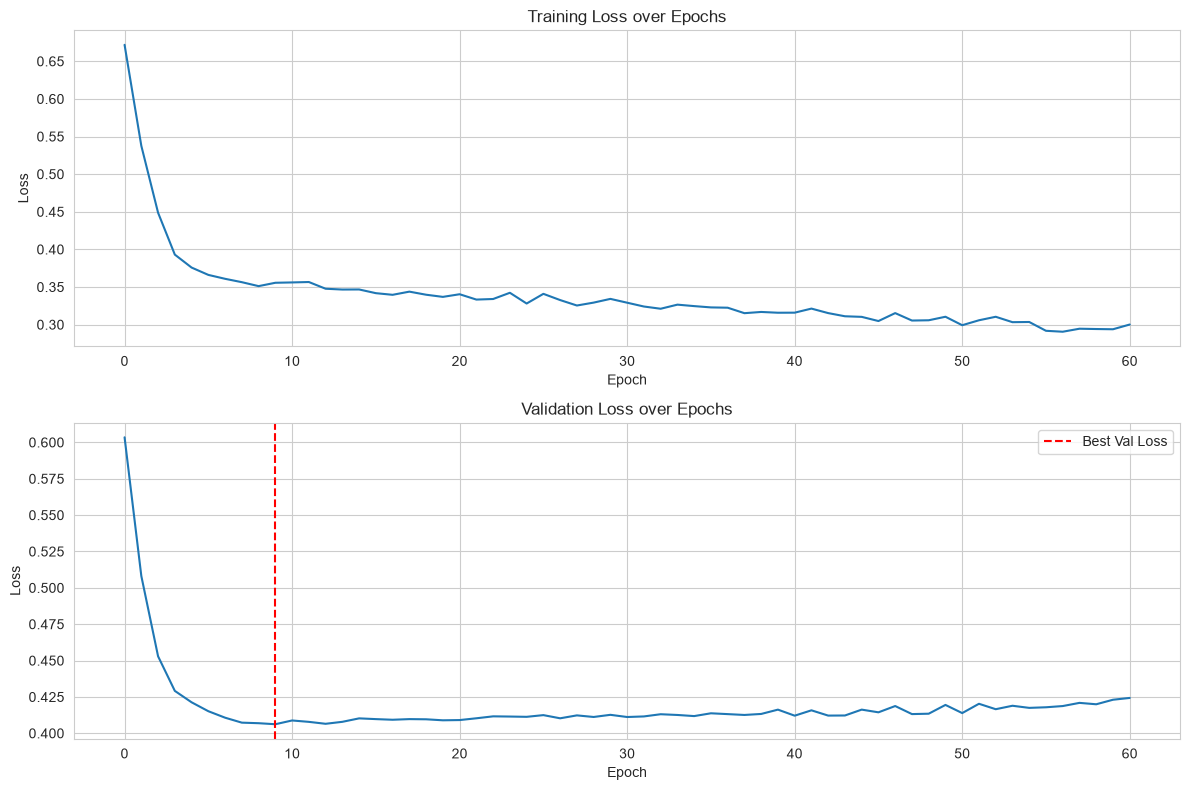

In [268]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(train_losses)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[0].set_title("Training Loss over Epochs")

ax[1].plot(val_losses)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].set_title("Validation Loss over Epochs")
ax[1].axvline(best_epoch, color="Red", linestyle="--", label="Best Val Loss")
ax[1].legend()

plt.tight_layout()
plt.show()

# 4. Model Evaluation

In [269]:
probs = model.forward(X_test_t)
y_pred = (probs >= 0.5).float()
acc = torch.mean((y_pred == y_test_t).float())

In [270]:
print(acc)

tensor(0.8360)


In [271]:
def confusion_matrix(y_pred, y):

    aa = torch.sum((y_pred == 1) & (y == 1))
    ab = torch.sum((y_pred == 1) & (y == 0))
    ba = torch.sum((y_pred == 0) & (y == 1))
    bb = torch.sum((y_pred == 0) & (y == 0))

    return np.array([[aa, ab], 
                    [ba, bb]])

In [272]:
mat = confusion_matrix(y_pred, y_test_t)
positive_precision = mat[0, 0] / (mat[0, 0] + mat[0, 1])
positive_recall = mat[0, 0] / (mat[0, 0] + mat[1, 0])
negative_precision = mat[1, 1] / (mat[1, 0] + mat[1, 1])
negative_recall = mat[1, 1] / (mat[1, 1] + mat[0, 1])

In [273]:
print("Performance Analysis")
print("-" * 30)
print(f"Confusion matrix: {mat}")
print(f"Positive Precision: {positive_precision :.2f}")
print(f"Negative Precision: {negative_precision :.2f}")
print(f"Positive Recall: {positive_recall:.2f}")
print(f"Negative Recall: {negative_recall:.2f}")

Performance Analysis
------------------------------
Confusion matrix: [[205  41]
 [  0   4]]
Positive Precision: 0.83
Negative Precision: 1.00
Positive Recall: 1.00
Negative Recall: 0.09


In [274]:
def sweep_threshold(probs, y, thresholds=np.linspace(0.01, 0.99, 99)):
    probs, y = probs.ravel(), y.ravel()
    best_t, best_score, rows = 0.5, -1.0, []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        tp = ((preds == 1) & (y == 1)).sum()
        tn = ((preds == 0) & (y == 0)).sum()
        fp = ((preds == 1) & (y == 0)).sum()
        fn = ((preds == 0) & (y == 1)).sum()
        tpr = tp / (tp + fn) if (tp + fn) else 0.0   # win recall
        tnr = tn / (tn + fp) if (tn + fp) else 0.0   # loss recall
        score = 0.5 * (tpr + tnr)                     # balanced accuracy
        rows.append((t, tpr, tnr, score))
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score, rows

In [275]:
best_t, best_score, rows = sweep_threshold(probs.detach().numpy(), y_test_t.detach().numpy())

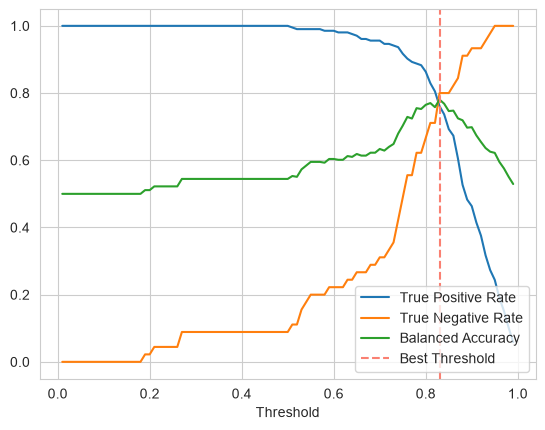

In [278]:
rows = np.array(rows)

plt.plot(np.linspace(0.01, 0.99, 99), rows[:, 1], label="True Positive Rate")
plt.plot(np.linspace(0.01, 0.99, 99), rows[:, 2], label="True Negative Rate")
plt.plot(rows[:, 0], rows[:, 3], label="Balanced Accuracy")
plt.axvline(best_t, color="Salmon", linestyle="--", label="Best Threshold")
plt.legend()
plt.xlabel("Threshold")
plt.show()